# Convolutional Neural Networks for Eye Disease Detection

## Authors

Laura Cahill, Olivia Jones-Martin, Roberto Mercado, Zuriel Pagan

## Dataset

We use the [Retinal Fundus Multi-disease Image Dataset (RFMiD)](https://ieee-dataport.org/open-access/retinal-fundus-multi-disease-image-dataset-rfmid?check_logged_in=1) for this project, which is available on the IEEE DataPort website. It contains 3200 fundus color images captured by three different fundus cameras. The dataset is divided into a training set of 1920 images, validation set of 640 images, and testing set of 640 images. Ground truth labels are provided through CSV files, which account for 1 healthy class and 45 disease classes. For this notebook, we used the dataset that was used in the RIADD Challenge, which contained 29 labels instead of 46.

## Prerequisites

The following Python 3.12 modules are required to execute the cells of this notebook.

In [ ]:
from collections import OrderedDict
from PIL import Image, ImageEnhance, ImageOps
from sklearn.metrics import multilabel_confusion_matrix,\
                            confusion_matrix,\
                            classification_report,\
                            accuracy_score,\
                            precision_score,\
                            recall_score,\
                            f1_score
from torch import nn
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from torchmetrics.classification import F1Score
from torchvision import transforms, models
import gc
import imageio.v2 as imageio
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import re
import seaborn as sns
import shutil
import sys
import torch
import torch.nn.functional as F

The following constants assume that the "RIADD Challenge" version of the dataset was downloaded from the IEEE DataPort website and placed into the same directory as this notebook.

In [3]:
DATA_PATH = 'A. RFMiD_All_Classes_Dataset'
IMAGE_PATH = f'{DATA_PATH}/1. Original Images'
GROUND_TRUTH_PATH = f'{DATA_PATH}/2. Groundtruths'
TRAINING_SET_PATH = f'{IMAGE_PATH}/a. Training Set'
VALIDATION_SET_PATH = f'{IMAGE_PATH}/b. Validation Set'
TESTING_SET_PATH = f'{IMAGE_PATH}/c. Testing Set'

It is highly recommended to run the models in this notebook on the GPU.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
display(device)

device(type='cuda')

## Data Compression

Given the size of the images within the dataset, we had to compress the images before we uploading them to University of Massachusetts Lowell's GPU servers. To do this, we cropped the black borders surrounding the eye images and shrank the images down to 1028x1028 using the following commented code. This allowed our dataset to fit within our alloted disk space on the GPU server.

### Obtaining Image Paths

In [4]:
# DATASET_DIR = "./A. RFMiD_All_Classes_Dataset"
# image_paths = []

# def listImages(directory: str, image_path_array: list):
#     for subpath in os.listdir(directory):
#         subpath = os.path.join(directory, subpath)
#         print(subpath)
#         if re.search(r'\.(jpg|jpeg|png)$', subpath):
#             image_path_array.append(os.path.join(subpath))
#         if os.path.isdir(os.path.join(subpath)):
#             listImages(subpath, image_path_array)

# listImages(DATASET_DIR, image_paths)
# print(image_paths)

### Obtaining Image Sizes

In [5]:
# image_size_list = []
# image_size_dict = dict()

# for image_path in image_paths:
#     img = Image.open(image_path)
#     image_size_list.append((img.width, img.height))
#     if f"{img.width}-{img.height}" not in image_size_dict:
#         image_size_dict[f"{img.width}-{img.height}"] = []
#     image_size_dict[f"{img.width}-{img.height}"].append(image_path)

# image_size_list = list(set(image_size_list))
# for size in image_size_list:
#     print(size)
#     print(image_size_dict[f"{size[0]}-{size[1]}"])

### Compressing Images

In [6]:
# for path in image_paths:

#     # Open the image
#     img = Image.open(path)

#     width, height = img.size

#     # if it is already cropped, skip it
#     if width == 1028 and height == 1028:
#         img.close()
#         continue

#     # Convert to grayscale to find the light vs dark
#     bw = img.convert('L')

#     # Make comparison image a tenth of the size, in a bilinear way, to blur out any excess pixels
#     bw = bw.resize((width // 10, height // 10), resample=Image.BILINEAR)

#     # bring back to original size
#     bw = bw.resize((width, height), resample=Image.BILINEAR)

#     bw = ImageEnhance.Contrast(bw).enhance(2.0)

#     # getbbox finds the box around the eye
#     eye_box = bw.getbbox()

#     #if eye_box is real:

#     if eye_box:
#         img = img.crop(eye_box)

#     else:
#         print(f"Warning: Could not find eye box for image {path}. Skipping cropping.")

#     # Resize eye box to 1028x1028
#     img = img.resize((1028, 1028))

#     #Save it
#     img.save(path)
#     img.close()

# print("images have been cropped and resized to 1028x1028!")

## ResNet-18

ResNet-18 served as one of our baseline models for handling multilabel classification of eye diseases. Laura worked on setting up and training the ResNet-18 model.

### Utilities

The following utility classes were used to aid in the training and evaluation of the ResNet-18 model. Some adjustments were made to the prediction steps to account for the multi-label outputs.

In [ ]:
class FundusImageDataset(Dataset):
    '''
    Represents a partition of the RFMiD dataset.
    '''
    def __init__(self, metadata, image_directory, transform):
        '''
        Initializes a new instance of the FundusImageDataset that contains the
        specified data frame, loads images from the specified directory, and
        modifies them using the specified transform.

        :self: The instance to initialize.
        :metadata: The data frame containing ground truth labels.
        :image_directory: The directory containing images in the dataset.
        :transform: The transform used to modify images loaded from the dataset.
        '''
        self.metadata = metadata
        self.image_directory = image_directory
        self.transform = transform

    def __len__(self):
        '''
        Returns the size of the FundusImageDataset.

        :self: The instance to get the size of.
        :return: The size of the EyeImageDataset.
        '''
        return len(self.metadata)

    def __getitem__(self, index):
        '''
        Returns an image and vector of ground truth labels at the specified row
        index from the FundusImageDataset.

        :self: The instance to search.
        :index: The row index of the desired image and vector of ground truth
                labels.
        :return: A tuple containing an image and vector of ground truth labels
                 at index.
        '''
        row = self.metadata.iloc[index]
        filepath = f'{self.image_directory}/{row['ID']}.png'
        image = self.transform(Image.open(filepath))
        labels = torch.from_numpy(row[1:].to_numpy(float))
        return image, labels

class ModelEvaluator:
    '''
    Provides methods that evaluate data models according to a set of
    configurations.
    '''
    def __init__(self,
                 training_loader,
                 validation_loader,
                 testing_loader,
                 loss_criterion,
                 optimizer,
                 device):
        '''
        Initializes a new instance of the ModelEvaluator class that evaluates
        data models on data loaded from the specified data loaders into the
        specified device using specified loss criterion and optimizer.

        :param self: The instance to initialize.
        :param training_loader: The data loader containing the training set.
        :param validation_loader: The data loader containing the validation set.
        :param testing_loader: The data loader containing the testing set.
        :param loss_criterion: The loss function to use during training.
        :param optimizer: The optimizer to use during training.
        :param device: The device to load data into.
        '''
        self.training_loader = training_loader
        self.validation_loader = validation_loader
        self.testing_loader = testing_loader
        self.loss_criterion = loss_criterion
        self.optimizer = optimizer
        self.device = device

    def train(self, model, epoch_count):
        '''
        Trains and validates the specified data model through the
        ModelEvaluator.
        '''
        training_accuracies = np.zeros(epoch_count)
        training_losses = np.zeros(epoch_count)
        validation_accuracies = np.zeros(epoch_count)
        validation_losses = np.zeros(epoch_count)

        for epoch in range(epoch_count):
            # Begin training loop.
            model.train()
            total_loss = 0.0
            total_samples = 0.0
            total_correct = 0.0

            print(f"epoch {epoch}: starting")

            for inputs, labels in self.training_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = model(inputs)

                # Use 0.3 here as well for consistency across your project
                predictions = (torch.sigmoid(outputs) > 0.60).float()

                loss = self.loss_criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()
                total_samples += labels.numel()
                total_correct += (predictions == labels).sum().item()

            training_accuracies[epoch] = total_correct / total_samples
            training_losses[epoch] = total_loss / len(self.training_loader)

            print("Training done. Onto validation.")

            # Begin validation loop.
            model.eval()
            val_labels = []
            val_preds = []
            val_total_loss = 0.0

            for inputs, labels in self.validation_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                with torch.no_grad():
                    outputs = model(inputs)
                    loss = self.loss_criterion(outputs, labels)
                    val_total_loss += loss.item()
                    predictions = (torch.sigmoid(outputs) > 0.60).float()

                val_labels.append(labels.cpu().numpy())
                val_preds.append(predictions.cpu().numpy())

            # Stack everything into two big matrices
            val_labels = np.vstack(val_labels)
            val_preds = np.vstack(val_preds)

            # Calculate Macro F1
            from sklearn.metrics import f1_score, accuracy_score
            epoch_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

            # Update the metric arrays
            # Using (val_preds == val_labels).mean() gives bit-wise accuracy (Hamming)
            # accuracy_score gives subset accuracy (all 29 must match perfectly)
            validation_accuracies[epoch] = (val_preds == val_labels).mean()
            validation_losses[epoch] = val_total_loss / len(self.validation_loader)

            print(f"epoch {epoch}: F1-Score: {epoch_f1:.4f} | Bit-Accuracy: {validation_accuracies[epoch]:.4f}")

        return TrainingMetrics(training_accuracies,
                               training_losses,
                               validation_accuracies,
                               validation_losses)

    def test(self, model, label_names=None):
        model.eval()
        all_labels = []
        all_probs = [] # Changed from all_preds to all_probs

        with torch.no_grad():
            for inputs, labels in self.testing_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = model(inputs)

                # Store RAW probabilities (0.0 to 1.0)
                probs = torch.sigmoid(outputs)

                all_labels.append(labels.cpu().numpy())
                all_probs.append(probs.cpu().numpy())

        # Combine all batches
        val_trues = np.vstack(all_labels)
        val_probs = np.vstack(all_probs)

        if label_names is None:
            label_names = [f"Class {i}" for i in range(val_trues.shape[1])]

        # --- Threshold Optimization ---
        best_thresholds = []
        for i in range(val_trues.shape[1]):
            best_f1 = -1
            best_thresh = 0.5

            y_prob = val_probs[:, i]
            y_true = val_trues[:, i]

            # Search for the best threshold for this specific disease
            for thresh in np.arange(0.05, 0.95, 0.01):
                y_pred = (y_prob >= thresh).astype(int)
                score = f1_score(y_true, y_pred, zero_division=0)
                if score > best_f1:
                    best_f1 = score
                    best_thresh = thresh
            best_thresholds.append(best_thresh)

        # Apply the optimized thresholds to get final predictions
        final_preds = np.zeros_like(val_probs)
        for i in range(val_trues.shape[1]):
            final_preds[:, i] = (val_probs[:, i] >= best_thresholds[i]).astype(int)

        # Generate the report
        print("Optimized Thresholds per class:")
        print(best_thresholds)

        report = classification_report(
            val_trues,
            final_preds,
            target_names=label_names,
            zero_division=0
        )

        print(report)
        return report, best_thresholds

class TrainingMetrics:
    '''
    Contains metrics that measure accuracy and loss across training epochs.
    '''
    def __init__(self,
                 training_accuracies,
                 training_losses,
                 validation_accuracies,
                 validation_losses):
        '''
        Initializes a new instance of the TrainingMetrics class that contains
        the specified lists of accuracies and losses obtained across training
        epochs.

        :param self: The instance to initialize.
        :param training_accuracies: The list of training accuracies.
        :param training_losses: The list of training losses.
        :param validation_accuracies: The list of validation accuracies.
        :param validation_losses: The list of validation losses.
        '''
        self.training_accuracies = training_accuracies
        self.training_losses = training_losses
        self.validation_accuracies = validation_accuracies
        self.validation_losses = validation_losses

    def show_accuracies(self):
        '''
        Shows a plot of the training and validation accuracies contained by the
        TrainingMetrics.

        :param self: The instance containing training and validation accuracies.
        '''
        epochs = range(1, len(self.training_accuracies) + 1)
        plt.figure(figsize=(10, 15))
        plt.subplot(2, 1, 2)
        plt.plot(epochs, self.training_accuracies, label='Training Accuracy')
        plt.plot(epochs, self.validation_accuracies, label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.legend()
        plt.figure()
        plt.show()

    def show_losses(self):
        '''
        Shows a plot of the training and validation losses contained by the
        TrainingMetrics.

        :param self: The instance containing training and validation losses.
        '''
        epochs = range(1, len(self.training_losses) + 1)
        plt.figure(figsize=(10, 15))
        plt.subplot(2, 1, 2)
        plt.plot(epochs, self.training_losses, label='Training Loss')
        plt.plot(epochs, self.validation_losses, label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.legend()
        plt.figure()
        plt.show()

### Dataset Setup

First, we need to set up the dataset for model evaluation. The dataset is presplit into training, validation, and testing sets already. Here, we load the metadata for each set.

In [ ]:
training_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/a. RFMiD_Training_Labels.csv')
validation_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/b. RFMiD_Validation_Labels.csv')
testing_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/c. RFMiD_Testing_Labels.csv')

Now, let's configure the dataset for use by ResNet-18. The FundusImageDataset class will handle the underlying logic for loading images and labels. We only need to supply the transform so that our images are properly sized for the model.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Higher resolution for small disease features
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

training_dataset = FundusImageDataset(training_metadata, TRAINING_SET_PATH, transform)
validation_dataset = FundusImageDataset(validation_metadata, VALIDATION_SET_PATH, transform)
testing_dataset = FundusImageDataset(testing_metadata, TESTING_SET_PATH, transform)

training_loader = DataLoader(training_dataset, batch_size=64, num_workers=6)
validation_loader = DataLoader(validation_dataset, batch_size=64, num_workers=6)
testing_loader = DataLoader(testing_dataset, batch_size=64, num_workers=7)

### Model Setup

Here, we set up ResNet-18 for use on our dataset.

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) #changed to resnet-18
model.aux_logits = False
model.fc = nn.Linear(model.fc.in_features, 29)
model = model.to(device)
display(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Then, we set up the class weights, loss function, and optimizer.

In [ ]:
# 1. Combine metadata
# (Since 'Othering' is already done in the CSVs, this just stacks them)
combined_metadata = pd.concat([training_metadata, validation_metadata, testing_metadata], ignore_index=True)

# 2. Extract only the label columns (dropping 'ID')
# This ensures we have exactly 29 columns
label_columns = combined_metadata.drop('ID', axis=1)
frequencies = label_columns.sum().to_numpy()

# 3. Calculate pos_weight for the 29 labels
# We use (Negative Samples / Positive Samples) for each class
# Adding 1e-6 prevents division by zero for extremely rare classes
total_samples = len(combined_metadata)
weights = np.sqrt((total_samples - frequencies) / (frequencies + 1e-6))
pos_weight = torch.FloatTensor(weights).to(device)

# 4. Initialize Model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, 29)
model.to(device)

# 5. Loss and Optimizer
# Passing pos_weight here is the key to fixing the 0.00 scores
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5) # Lower LR for stability

# Display to verify the weights aren't all the same
print("Weights for the 29 labels:")
display(pos_weight)

Weights for the 29 labels:


tensor([ 0.5141,  2.0158,  4.2350,  2.2624,  3.5935,  4.2617,  5.0883,  3.0865,
        11.0488,  6.2854, 10.8406,  7.1735,  2.4882,  8.3732, 17.8606, 11.2694,
         5.1794,  5.6862, 17.0267, 11.0488, 13.6834, 11.2694,  6.6386,  7.6328,
        11.5036,  9.9499, 13.6834, 17.8606,  6.6869], device='cuda:0')

### Model Evaluation

epoch1 done
epoch2 done
epoch3 done
epoch4 done
epoch5 done
epoch6 done
epoch7 done
epoch8 done
epoch9 done
epoch10 done
epoch11 done
epoch12 done
epoch13 done
epoch14 done
epoch15 done
epoch16 done
epoch17 done
epoch18 done
epoch19 done
epoch20 done


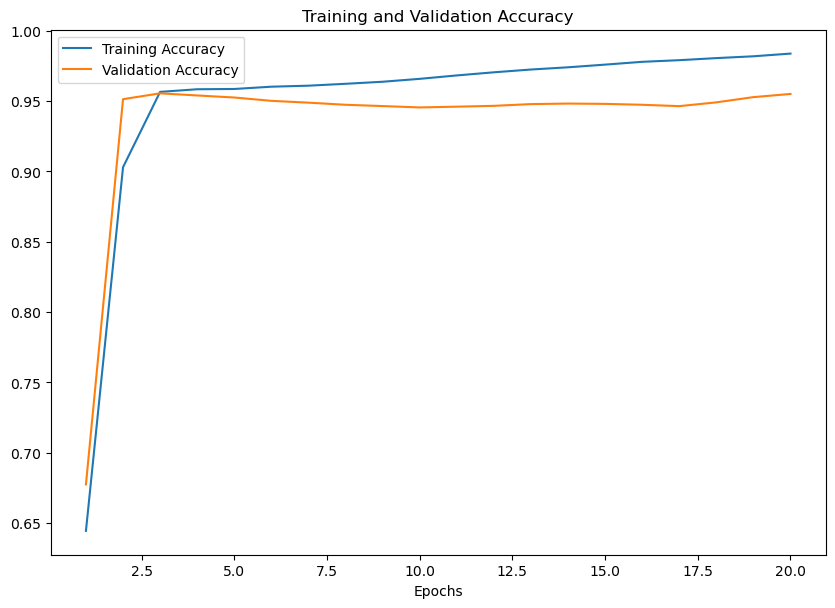

<Figure size 640x480 with 0 Axes>

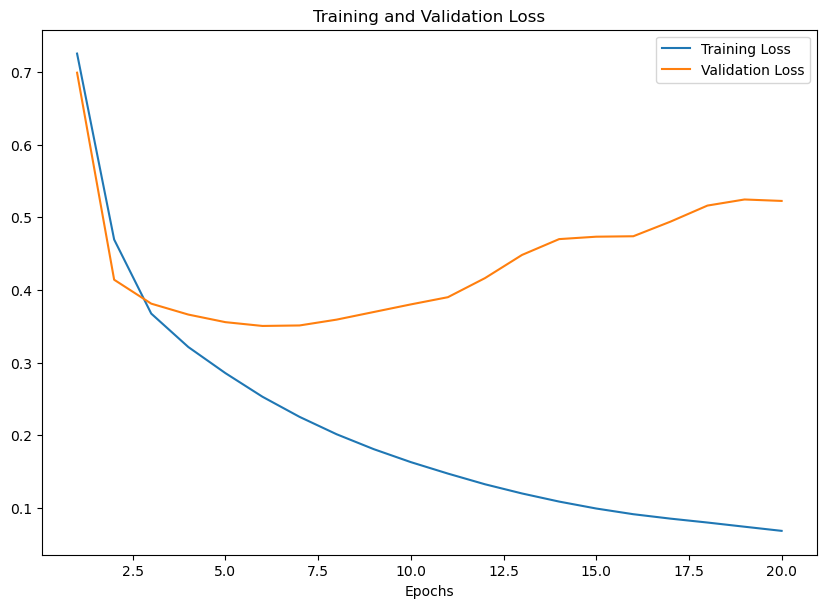

<Figure size 640x480 with 0 Axes>

In [ ]:
evaluator = ModelEvaluator(
    training_loader,
    validation_loader,
    testing_loader,
    criterion,
    optimizer,
    device
)

results = evaluator.train(model, 20)
results.show_accuracies()
results.show_losses()

The results show that the ResNet-18 model is getting high accuracies with a roughly 3 epochs. The validation accuracy did falter afterwards, but the training accuracy did increase steadily.

In [ ]:
# 1. Get the list of disease names (skipping the 'ID' column)
disease_names = testing_metadata.columns[1:].tolist()

# 2. Run the test method and pass those names in
evaluator.test(model)

array([[[126,   8],
        [ 73, 433]],

       [[500,  16],
        [ 57,  67]],

       [[606,   3],
        [ 23,   8]],

       [[472,  64],
        [  7,  97]],

       [[588,   6],
        [ 43,   3]],

       [[591,  17],
        [  3,  29]],

       [[586,  31],
        [  9,  14]],

       [[580,   7],
        [ 44,   9]],

       [[634,   1],
        [  5,   0]],

       [[625,   0],
        [ 14,   1]],

       [[633,   0],
        [  7,   0]],

       [[627,   0],
        [ 13,   0]],

       [[439, 110],
        [ 40,  51]],

       [[622,   9],
        [  3,   6]],

       [[638,   0],
        [  2,   0]],

       [[634,   1],
        [  2,   3]],

       [[610,   6],
        [ 22,   2]],

       [[623,   0],
        [  9,   8]],

       [[638,   0],
        [  2,   0]],

       [[636,   0],
        [  4,   0]],

       [[632,   4],
        [  4,   0]],

       [[635,   0],
        [  5,   0]],

       [[624,   2],
        [ 12,   2]],

       [[629,   0],
        [ 11, 

The confusion matrices show that the ResNet-18 model is able to identify cases where eye disease is present really well. However, it does have a lot of trouble classifying specific diseases, especially the rare ones (which the model has grown accustomed to make negative predictions on). This is common trend we will see across all of our models.

## ResNet-34

ResNet-34 served as one of our baseline models for handling multilabel classification of eye diseases. Zuriel worked on setting up and training the ResNet-34 model.

### Notes on Results and Limitations

Due to time constraints, the final experimental results and detailed evaluation metrics were not fully incorporated into this section of the notebook. While the model training pipeline and preprocessing steps were completed, the process of running extended experiments, tuning hyperparameters, and generating comprehensive performance visualizations was not finalized.

Additionally, server-related issues significantly impacted the ability to complete training runs and save consistent outputs. Interruptions in compute availability and instability during long training sessions prevented reliable collection of results across multiple epochs and configurations.

As a result, this section primarily demonstrates the implementation and setup of the ResNet34-based model rather than a complete experimental analysis. Future work would involve re-running experiments in a stable environment, collecting performance metrics (e.g., accuracy, precision, recall, F1-score), and adding visualizations such as loss curves and confusion matrices to provide a more thorough evaluation.

### Utilities

The following utility classes were used to aid in the training and evaluation of the ResNet-34 model. Like ResNet-18, some adjustments were made to the prediction steps to account for the multi-label outputs.

In [ ]:
class FundusImageDataset(Dataset):
    '''
    Represents a partition of the RFMiD dataset.
    '''
    def __init__(self, metadata, image_directory, transform):
        '''
        Initializes a new instance of the FundusImageDataset that contains the
        specified data frame, loads images from the specified directory, and
        modifies them using the specified transform.

        :self: The instance to initialize.
        :metadata: The data frame containing ground truth labels.
        :image_directory: The directory containing images in the dataset.
        :transform: The transform used to modify images loaded from the dataset.
        '''
        self.metadata = metadata
        self.image_directory = image_directory
        self.transform = transform
        self.classes = metadata.columns[1:].to_numpy()

    def __len__(self):
        '''
        Returns the size of the FundusImageDataset.

        :self: The instance to get the size of.
        :return: The size of the EyeImageDataset.
        '''
        return len(self.metadata)

    def __getitem__(self, index):
        '''
        Returns an image and vector of ground truth labels at the specified row
        index from the FundusImageDataset.

        :self: The instance to search.
        :index: The row index of the desired image and vector of ground truth
                labels.
        :return: A tuple containing an image and vector of ground truth labels
                 at index.
        '''
        row = self.metadata.iloc[index]
        filepath = f'{self.image_directory}/{row['ID']}.png'
        image = self.transform(Image.open(filepath))
        labels = torch.from_numpy(row[1:].to_numpy(float))
        return image, labels

class ModelEvaluator:
    '''
    Provides methods that evaluate data models according to a set of
    configurations.
    '''
    def __init__(self,
                 training_loader,
                 validation_loader,
                 testing_loader,
                 loss_criterion,
                 optimizer,
                 device):
        '''
        Initializes a new instance of the ModelEvaluator class that evaluates
        data models on data loaded from the specified data loaders into the
        specified device using specified loss criterion and optimizer.

        :param self: The instance to initialize.
        :param training_loader: The data loader containing the training set.
        :param validation_loader: The data loader containing the validation set.
        :param testing_loader: The data loader containing the testing set.
        :param loss_criterion: The loss function to use during training.
        :param optimizer: The optimizer to use during training.
        :param device: The device to load data into.
        '''
        self.training_loader = training_loader
        self.validation_loader = validation_loader
        self.testing_loader = testing_loader
        self.loss_criterion = loss_criterion
        self.optimizer = optimizer
        self.device = device

    def train(self, model, epoch_count):
        '''
        Trains and validates the specified data model through the
        ModelEvaluator.

        :param self: The ModelEvaluator.
        :param model: The data model to train and validate.
        :return: A new instance of the TrainingMetrics class that contains
                 training accuracy and loss metrics.
        '''
        training_accuracies = np.zeros(epoch_count)
        training_losses = np.zeros(epoch_count)
        validation_accuracies = np.zeros(epoch_count)
        validation_losses = np.zeros(epoch_count)

        for epoch in range(epoch_count):
            # Begin training loop.
            total_loss = 0.0
            total_samples = 0.0
            total_correct = 0.0

            for inputs, labels in self.training_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = model(inputs)
                predictions = (torch.sigmoid(outputs) > 0.5).float()
                loss = self.loss_criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
                total_samples += labels.numel()
                total_correct += (predictions == labels).sum().item()

            training_accuracies[epoch] = total_correct / total_samples
            training_losses[epoch] = total_loss / len(self.training_loader)

            # Begin validation loop.
            total_loss = 0.0
            total_samples = 0.0
            total_correct = 0.0
            model.eval()

            for inputs, labels in self.validation_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = model(inputs)
                predictions = (torch.sigmoid(outputs) > 0.5).float()
                loss = self.loss_criterion(outputs, labels)
                total_loss += loss.item()
                total_samples += labels.numel()
                total_correct += (predictions == labels).sum().item()

            validation_accuracies[epoch] = total_correct / total_samples
            validation_losses[epoch] = total_loss / len(self.validation_loader)

        return TrainingMetrics(training_accuracies,
                               training_losses,
                               validation_accuracies,
                               validation_losses)

    def test(self, model):
        '''
        Tests the specified data model through the ModelEvaluator.

        :param self: The ModelEvaluator.
        :param model: The data model to test.
        :return: A numpy array containing confusion matrices for each label.
        '''
        label_count = len(self.testing_loader.dataset.classes)
        matrices = np.zeros((label_count, 2, 2), dtype=int)
        model.eval()

        with torch.no_grad():
            for inputs, labels in self.testing_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = model(inputs)
                predictions = (torch.sigmoid(outputs) > 0.5).float()
                labels = labels.cpu().numpy()
                predictions = predictions.cpu().numpy()
                matrices += multilabel_confusion_matrix(labels, predictions)

        return matrices

class TrainingMetrics:
    '''
    Contains metrics that measure accuracy and loss across training epochs.
    '''
    def __init__(self,
                 training_accuracies,
                 training_losses,
                 validation_accuracies,
                 validation_losses):
        '''
        Initializes a new instance of the TrainingMetrics class that contains
        the specified lists of accuracies and losses obtained across training
        epochs.

        :param self: The instance to initialize.
        :param training_accuracies: The list of training accuracies.
        :param training_losses: The list of training losses.
        :param validation_accuracies: The list of validation accuracies.
        :param validation_losses: The list of validation losses.
        '''
        self.training_accuracies = training_accuracies
        self.training_losses = training_losses
        self.validation_accuracies = validation_accuracies
        self.validation_losses = validation_losses

    def show_accuracies(self):
        '''
        Shows a plot of the training and validation accuracies contained by the
        TrainingMetrics.

        :param self: The instance containing training and validation accuracies.
        '''
        epochs = range(1, len(self.training_accuracies) + 1)
        plt.figure(figsize=(10, 15))
        plt.subplot(2, 1, 2)
        plt.plot(epochs, self.training_accuracies, label='Training Accuracy')
        plt.plot(epochs, self.validation_accuracies, label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.legend()
        plt.figure()
        plt.show()

    def show_losses(self):
        '''
        Shows a plot of the training and validation losses contained by the
        TrainingMetrics.

        :param self: The instance containing training and validation losses.
        '''
        epochs = range(1, len(self.training_losses) + 1)
        plt.figure(figsize=(10, 15))
        plt.subplot(2, 1, 2)
        plt.plot(epochs, self.training_losses, label='Training Loss')
        plt.plot(epochs, self.validation_losses, label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.legend()
        plt.figure()
        plt.show()

### Dataset Setup

First, we need to set up the dataset for model evaluation. The dataset is presplit into training, validation, and testing sets already.

In [ ]:
training_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/a. RFMiD_Training_Labels.csv')
validation_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/b. RFMiD_Validation_Labels.csv')
testing_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/c. RFMiD_Testing_Labels.csv')

Now, let's configure the dataset for use by ResNet-34. The FundusImageDataset class will handle the underlying logic for loading images and labels. We only need to supply the transform so that our images are properly sized for the model.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((448, 448)), # Higher resolution for small disease features
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

training_dataset = FundusImageDataset(training_metadata, TRAINING_SET_PATH, transform)
validation_dataset = FundusImageDataset(validation_metadata, VALIDATION_SET_PATH, transform)
testing_dataset = FundusImageDataset(testing_metadata, TESTING_SET_PATH, transform)

training_loader = DataLoader(training_dataset, batch_size=32, num_workers=6)
validation_loader = DataLoader(validation_dataset, batch_size=32, num_workers=6)
testing_loader = DataLoader(testing_dataset, batch_size=32, num_workers=6)

### Model Setup

Here, we set up ResNet-34 for use on our dataset.

In [ ]:
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 29)
model = model.to(device)
display(model)

Then, we set up the class weights, loss function, and optimizer.

In [ ]:
# 1. Combine metadata
# (Since 'Othering' is already done in the CSVs, this just stacks them)
combined_metadata = pd.concat([training_metadata, validation_metadata, testing_metadata], ignore_index=True)

# 2. Extract only the label columns (dropping 'ID')
# This ensures we have exactly 29 columns
label_columns = combined_metadata.drop('ID', axis=1)
frequencies = label_columns.sum().to_numpy()

# 3. Calculate pos_weight for the 29 labels
# Adding 1e-6 prevents division by zero for extremely rare classes
total_samples = len(combined_metadata)
weights = np.sqrt((total_samples - frequencies) / (frequencies + 1e-6))
pos_weight = torch.FloatTensor(weights).to(device)

# 4. Initialize Model
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, 29)
model.to(device)

# 5. Loss and Optimizer
# Passing pos_weight here is the key to fixing the 0.00 scores
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5) # Lower LR for stability

# Display to verify the weights aren't all the same
print("Weights for the 29 labels:")
display(pos_weight)

### Model Evaluation

In [ ]:
evaluator = ModelEvaluator(
    training_loader,
    validation_loader,
    testing_loader,
    criterion,
    optimizer,
    device
)

results = evaluator.train(model, 20)
results.show_accuracies()
results.show_losses()

In [ ]:
# 1. Get the list of disease names (skipping the 'ID' column)
disease_names = testing_metadata.columns[1:].tolist()

# 2. Run the test method and pass those names in
evaluator.test(model, label_names=disease_names)

## Inception v3

Inception v3 served as our primary model for handling multilabel classification of eye diseases. Roberto worked on setting up and training the Inception v3 model.

### Utilities

The following utility classes were used to aid in the training and evaluation of the Inception v3 model. Like the previous models, some adjustments were made to the prediction steps to account for the multi-label outputs. The main difference from the previous methods is the use of a learning rate scheduler to control learning across training epochs.

In [ ]:
class FundusImageDataset(Dataset):
    '''
    Represents a partition of the RFMiD dataset.
    '''
    def __init__(self, metadata, image_directory, transform):
        '''
        Initializes a new instance of the FundusImageDataset that contains the
        specified data frame, loads images from the specified directory, and
        modifies them using the specified transform.

        :self: The instance to initialize.
        :metadata: The data frame containing ground truth labels.
        :image_directory: The directory containing images in the dataset.
        :transform: The transform used to modify images loaded from the dataset.
        '''
        self.metadata = metadata
        self.image_directory = image_directory
        self.transform = transform
        self.classes = metadata.columns[1:].to_numpy()

    def __len__(self):
        '''
        Returns the size of the FundusImageDataset.

        :self: The instance to get the size of.
        :return: The size of the EyeImageDataset.
        '''
        return len(self.metadata)

    def __getitem__(self, index):
        '''
        Returns an image and vector of ground truth labels at the specified row
        index from the FundusImageDataset.

        :self: The instance to search.
        :index: The row index of the desired image and vector of ground truth
                labels.
        :return: A tuple containing an image and vector of ground truth labels
                 at index.
        '''
        row = self.metadata.iloc[index]
        filepath = f'{self.image_directory}/{row['ID']}.png'
        image = self.transform(Image.open(filepath))
        labels = torch.from_numpy(row[1:].to_numpy().astype(np.float32))
        return image, labels

class ModelEvaluator:
    '''
    Provides methods that evaluate data models according to a set of
    configurations.
    '''
    def __init__(self,
                 training_loader,
                 validation_loader,
                 testing_loader,
                 loss_criterion,
                 optimizer,
                 device,
                 lr_scheduler=None):
        '''
        Initializes a new instance of the ModelEvaluator class that evaluates
        data models on data loaded from the specified data loaders into the
        specified device using specified loss criterion and optimizer.

        :param self: The instance to initialize.
        :param training_loader: The data loader containing the training set.
        :param validation_loader: The data loader containing the validation set.
        :param testing_loader: The data loader containing the testing set.
        :param loss_criterion: The loss function to use during training.
        :param optimizer: The optimizer to use during training.
        :param device: The device to load data into.
        :param lr_scheduler: The learning rate scheduler to use during training.
        '''
        self.training_loader = training_loader
        self.validation_loader = validation_loader
        self.testing_loader = testing_loader
        self.loss_criterion = loss_criterion
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.device = device
        self.scaler = GradScaler()

    def train(self, model, epoch_count, verbose=False):
        '''
        Trains and validates the specified data model through the
        ModelEvaluator.

        :param self: The ModelEvaluator.
        :param model: The data model to train and validate.
        :param verbose: Wether or not epochs are printed
        :return: A new instance of the TrainingMetrics class that contains
                 training accuracy and loss metrics.
        '''
        training_accuracies = np.zeros(epoch_count)
        training_losses = np.zeros(epoch_count)
        validation_accuracies = np.zeros(epoch_count)
        validation_losses = np.zeros(epoch_count)

        for epoch in range(epoch_count):
            # Begin training loop.
            total_loss = 0.0
            total_samples = 0.0
            total_correct = 0.0

            for inputs, labels in self.training_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                with autocast(device_type=self.device.type):
                    outputs = model(inputs)
                    predictions = (torch.sigmoid(outputs) > 0.5).float()
                    loss = self.loss_criterion(outputs, labels)
                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()
                total_loss += loss.item()
                total_samples += labels.numel()
                total_correct += (predictions == labels).sum().item()

            # Advance the scheduler after the training epoch.
            if self.lr_scheduler:
                self.lr_scheduler.step()

            training_accuracies[epoch] = total_correct / total_samples
            training_losses[epoch] = total_loss / len(self.training_loader)

            # Begin validation loop.
            total_loss = 0.0
            total_samples = 0.0
            total_correct = 0.0
            model.eval()

            for inputs, labels in self.validation_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = model(inputs)
                predictions = (torch.sigmoid(outputs) > 0.5).float()
                loss = self.loss_criterion(outputs, labels)
                total_loss += loss.item()
                total_samples += labels.numel()
                total_correct += (predictions == labels).sum().item()

            validation_accuracies[epoch] = total_correct / total_samples
            validation_losses[epoch] = total_loss / len(self.validation_loader)

            if verbose:
                print(f"Epoch: {epoch+1}")
                print(f"Loss: {training_losses[epoch]} Accuracy: {training_accuracies[epoch]}")
                print(f"Validation Loss: {validation_losses[epoch]} Val Accuracy: {validation_accuracies[epoch]}")

        return TrainingMetrics(training_accuracies,
                               training_losses,
                               validation_accuracies,
                               validation_losses)

    def test(self, model):
        '''
        Tests the specified data model through the ModelEvaluator.

        :param self: The ModelEvaluator.
        :param model: The data model to test.
        :return: A numpy array containing confusion matrices for each label.
        '''
        label_count = len(self.testing_loader.dataset.classes)
        matrices = np.zeros((label_count, 2, 2), dtype=int)
        model.eval()

        with torch.no_grad():
            for inputs, labels in self.testing_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = model(inputs)
                predictions = (torch.sigmoid(outputs) > 0.5).float()
                labels = labels.cpu().numpy()
                predictions = predictions.cpu().numpy()

                # MultiLabel matrices are used to track the
                # performance of the model across each class.
                matrices += multilabel_confusion_matrix(labels, predictions)

        return matrices

class TrainingMetrics:
    '''
    Contains metrics that measure accuracy and loss across training epochs.
    '''
    def __init__(self,
                 training_accuracies,
                 training_losses,
                 validation_accuracies,
                 validation_losses):
        '''
        Initializes a new instance of the TrainingMetrics class that contains
        the specified lists of accuracies and losses obtained across training
        epochs.

        :param self: The instance to initialize.
        :param training_accuracies: The list of training accuracies.
        :param training_losses: The list of training losses.
        :param validation_accuracies: The list of validation accuracies.
        :param validation_losses: The list of validation losses.
        '''
        self.training_accuracies = training_accuracies
        self.training_losses = training_losses
        self.validation_accuracies = validation_accuracies
        self.validation_losses = validation_losses

    def show_accuracies(self):
        '''
        Shows a plot of the training and validation accuracies contained by the
        TrainingMetrics.

        :param self: The instance containing training and validation accuracies.
        '''
        epochs = range(1, len(self.training_accuracies) + 1)
        plt.figure(figsize=(10, 15))
        plt.subplot(2, 1, 2)
        plt.plot(epochs, self.training_accuracies, label='Training Accuracy')
        plt.plot(epochs, self.validation_accuracies, label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.legend()
        plt.figure()
        plt.show()

    def show_losses(self):
        '''
        Shows a plot of the training and validation losses contained by the
        TrainingMetrics.

        :param self: The instance containing training and validation losses.
        '''
        epochs = range(1, len(self.training_losses) + 1)
        plt.figure(figsize=(10, 15))
        plt.subplot(2, 1, 2)
        plt.plot(epochs, self.training_losses, label='Training Loss')
        plt.plot(epochs, self.validation_losses, label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.legend()
        plt.figure()
        plt.show()

### Dataset Setup

First, we need to set up the dataset for model evaluation. The dataset is presplit into training, validation, and testing sets already. Note that Roberto converted the Disease Risk class to the Healthy class here. He did this mostly to make it easier to see how the model is classifying healthy cases.

In [ ]:
training_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/a. RFMiD_Training_Labels.csv')
validation_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/b. RFMiD_Validation_Labels.csv')
testing_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/c. RFMiD_Testing_Labels.csv')

for metadata in (training_metadata, validation_metadata, testing_metadata):
    metadata.rename(columns={'Disease_Risk' : 'Healthy'}, inplace=True)
    metadata['Healthy'] = metadata['Healthy'].apply(lambda value: int(not value))

Now, let's configure the dataset for use by Inception v3. The FundusImageDataset class will handle the underlying logic for loading images and labels. We only need to supply the transform so that our images are properly sized for the model.

In [ ]:
transform = transforms.Compose([
    transforms.Resize(299),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

training_dataset = FundusImageDataset(training_metadata, TRAINING_SET_PATH, transform)
validation_dataset = FundusImageDataset(validation_metadata, VALIDATION_SET_PATH, transform)
testing_dataset = FundusImageDataset(testing_metadata, TESTING_SET_PATH, transform)

batch_size = 16
num_workers = 16

training_sampler = torch.utils.data.RandomSampler(training_dataset)
validation_sampler = torch.utils.data.RandomSampler(validation_dataset)
testing_sampler = torch.utils.data.SequentialSampler(testing_dataset)

training_loader = DataLoader(training_dataset, batch_size=batch_size, sampler=training_sampler, num_workers=num_workers)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, sampler=validation_sampler, num_workers=num_workers)
testing_loader = DataLoader(testing_dataset, batch_size=batch_size, sampler=testing_sampler, num_workers=num_workers)

### Model Setup

Here, we set up Inception v3 for use on our dataset.

In [ ]:
model = models.inception_v3(init_weights=True)
model.fc = nn.Linear(model.fc.in_features, 29)

# Disable unused aux layer in favor of standard output layer
model.aux_logits = False
model.AuxLogits = None
model = model.to(device)
display(model)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

Then, we set up the class weights, loss function, and optimizer. We use Adam with the StepLR scheduler to improve the model's performance.

In [ ]:
disease_labels = training_metadata.columns[1:]

# counts includes every class except for ID
counts = training_metadata.iloc[:, 1:].sum()
print("Disease Counts:")
print(counts)

# total amount of images and labels in the training set
image_count = training_metadata.shape[0]
label_count = counts.shape[0]
print(f"Image count: {image_count}")
print(f"Label count: {label_count}")

'''
If there is an instance where a disease appears 0 times, give a warning and
set the count value to one to prevent a divide by zero error when calculating
the weights
'''
for i in range(label_count):
    if counts.iloc[i] == 0:
        counts.iloc[i] = 1
        print(f"WARNING! Zero instances of {disease_labels[i]} in dataset")

'''
Calculate pos_weights for binary cross entropy with logits loss
pos weight for a class should be (negative counts of class)/(positive counts of class)
Documentation in reference 2
'''
pos_weights = [math.log1p((image_count - count) / count) for count in counts]
print("pos_weigths for BCEWithLogitsLoss")
print(pos_weights)

Disease Counts:
Healthy    401
DR         376
ARMD       100
MH         317
DN         138
MYA        101
BRVO        73
TSLN       186
ERM         14
LS          47
MS          15
CSR         37
ODC        282
CRVO        28
TV           6
AH          16
ODP         65
ODE         58
ST           5
AION        17
PT          11
RT          14
RS          43
CRS         32
EDN         15
RPEC        22
MHL         11
RP           6
OTHER       34
dtype: int64
Image count: 1920
Label count: 29
pos_weigths for BCEWithLogitsLoss
[1.566119037715258, 1.6304913216319328, 2.9549102790337356, 1.8011786911445467, 2.6328267798646223, 2.9449599481805677, 3.269621023873436, 2.3343337913086257, 4.9210231354065685, 3.7099328633117685, 4.852030263919617, 3.9491625523776026, 1.9181733940837136, 4.227875954846623, 5.768320995793772, 4.787491742782046, 3.38569319512619, 3.499637454475408, 5.950642552587727, 4.726867120965611, 5.162185192223457, 4.9210231354065685, 3.798880349328265, 4.0943445622221, 4.8

In [ ]:
# Create loss function with given weights calculated
pos_weights = torch.FloatTensor(pos_weights).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weights).cuda()

# Create Adam optimizer with StepLR scheduler.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=1e-5)

### Model Evaluation

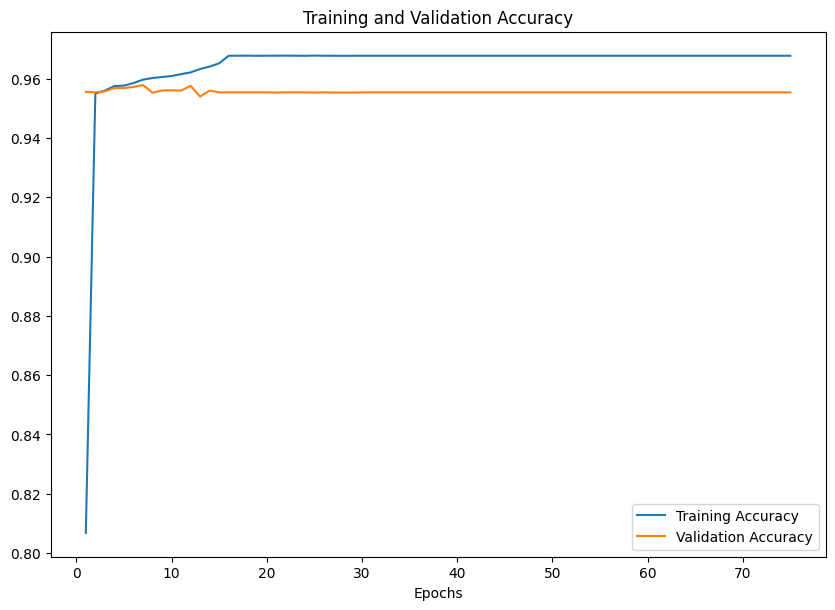

<Figure size 640x480 with 0 Axes>

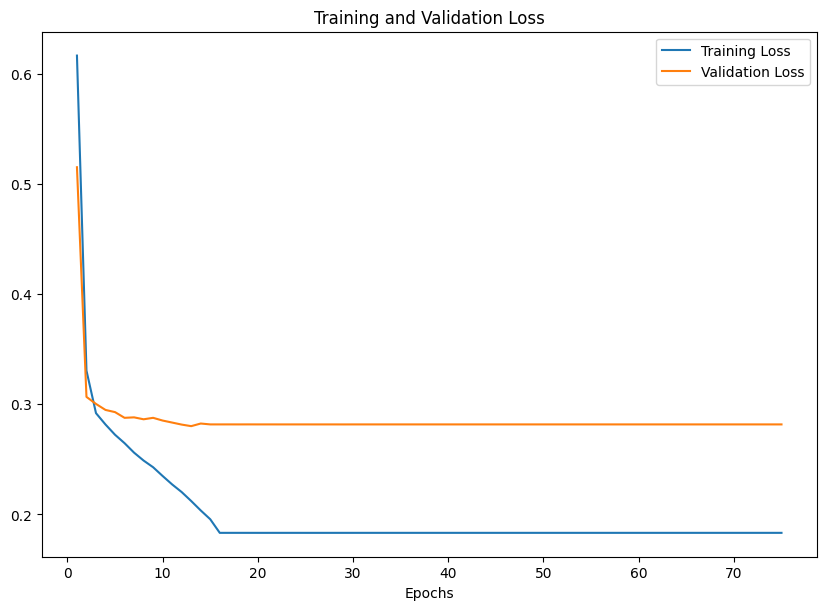

<Figure size 640x480 with 0 Axes>

In [ ]:
evaluator = ModelEvaluator(
    training_loader,
    validation_loader,
    testing_loader,
    criterion,
    optimizer,
    device,
    lr_scheduler=lr_scheduler
)

results = evaluator.train(model, 75)
results.show_accuracies()
results.show_losses()

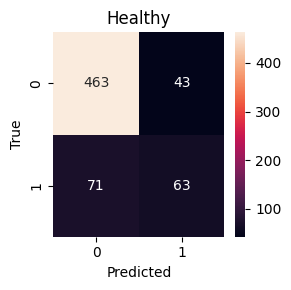

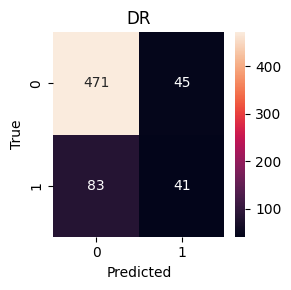

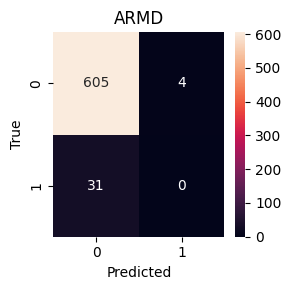

/tmp/ipykernel_3072670/1614561381.py:21: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * precision * recall / (precision + recall)


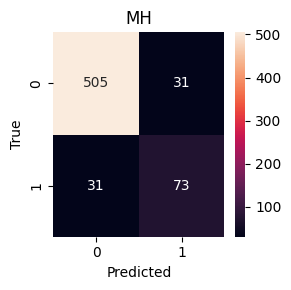

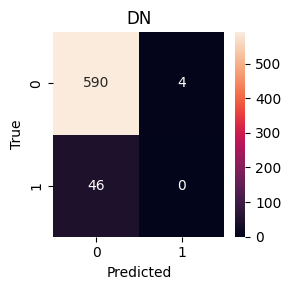

/tmp/ipykernel_3072670/1614561381.py:21: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * precision * recall / (precision + recall)


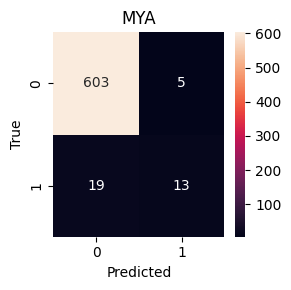

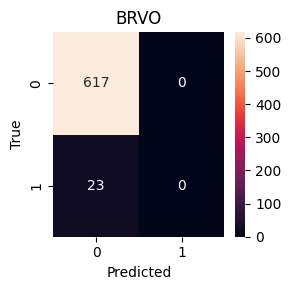

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


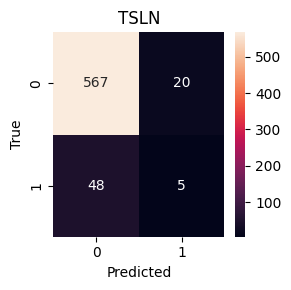

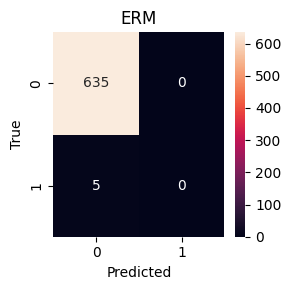

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


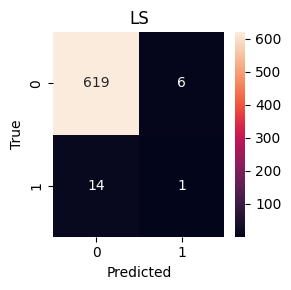

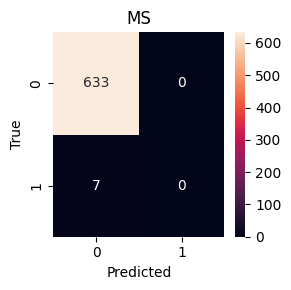

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


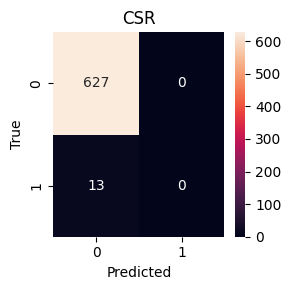

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


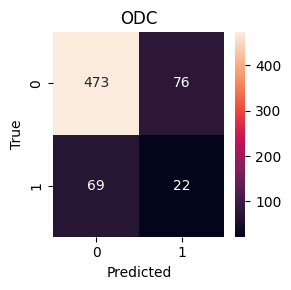

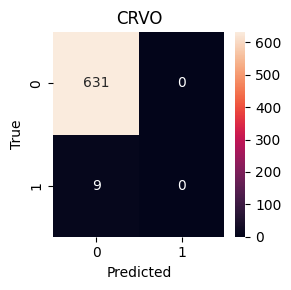

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


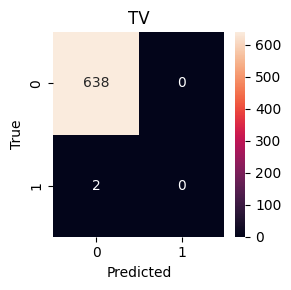

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


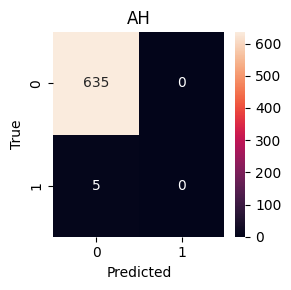

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


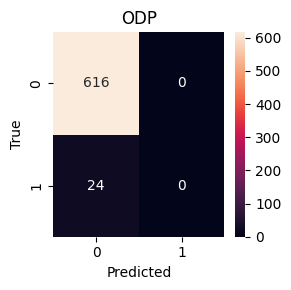

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


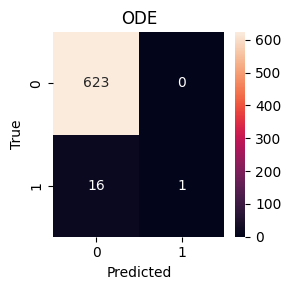

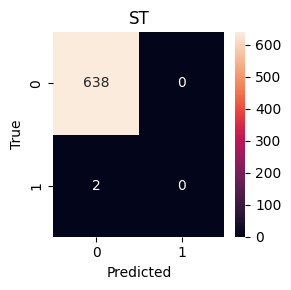

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


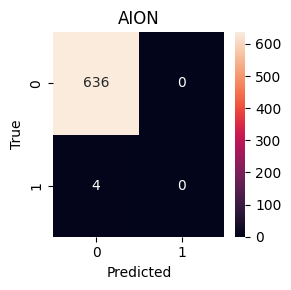

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


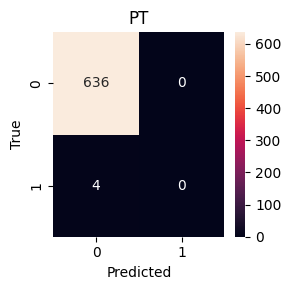

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


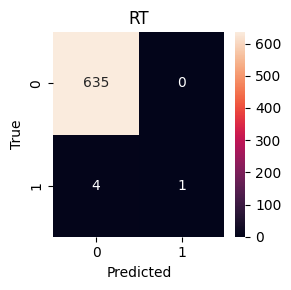

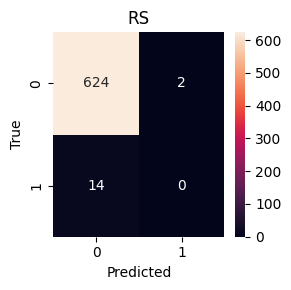

/tmp/ipykernel_3072670/1614561381.py:21: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * precision * recall / (precision + recall)


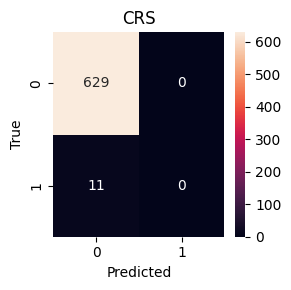

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


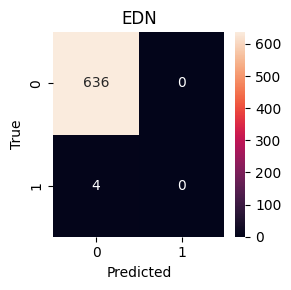

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


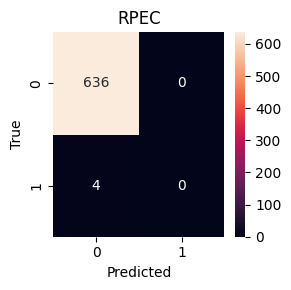

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


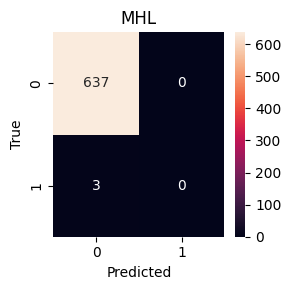

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


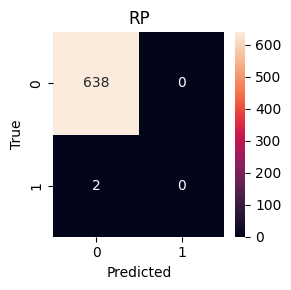

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


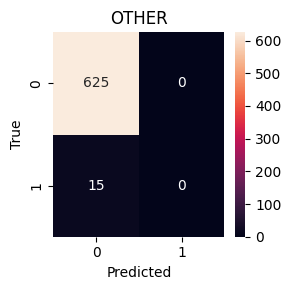

/tmp/ipykernel_3072670/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


,Accuracy,Precision,Recall,F1 Score
Healthy,0.821875,0.594340,0.470149,0.525000
DR,0.800000,0.476744,0.330645,0.390476
ARMD,0.945312,0.000000,0.000000,NaN
MH,0.903125,0.701923,0.701923,0.701923
DN,0.921875,0.000000,0.000000,NaN
MYA,0.962500,0.722222,0.406250,0.520000
BRVO,0.964063,NaN,0.000000,NaN
TSLN,0.893750,0.200000,0.094340,0.128205
ERM,0.992188,NaN,0.000000,NaN
LS,0.968750,0.142857,0.066667,0.090909


In [ ]:
matrices = evaluator.test(model)
metrics = pd.DataFrame(
    data={'Accuracy' : [0.0] * len(testing_dataset.classes),
          'Precision' : [0.0] * len(testing_dataset.classes),
          'Recall' : [0.0] * len(testing_dataset.classes),
          'F1 Score' : [0.0] * len(testing_dataset.classes)},
    index=testing_dataset.classes)

for label, matrix in zip(testing_dataset.classes, matrices):
    plt.figure(figsize=(3, 3))
    sns.heatmap(matrix, annot=True, fmt='d')
    plt.title(label)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
    tn, fp, fn, tp = matrix.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1_score = 2 * precision * recall / (precision + recall)
    metrics.at[label, 'Accuracy'] = accuracy
    metrics.at[label, 'Precision'] = precision
    metrics.at[label, 'Recall'] = recall
    metrics.at[label, 'F1 Score'] = f1_score

display(metrics)

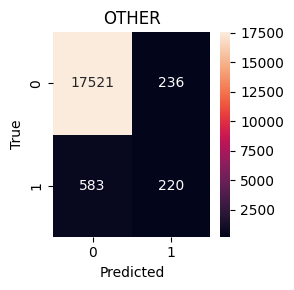

 Accuracy: 0.9558728448275862
Precision: 0.4824561403508772
   Recall: 0.273972602739726
 F1 Score: 0.34948371723590155


In [ ]:
matrix = matrices.sum(axis=0)
plt.figure(figsize=(3, 3))
sns.heatmap(matrix, annot=True, fmt='d')
plt.title(label)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()
tn, fp, fn, tp = matrix.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * precision * recall / (precision + recall)
print(f' Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'   Recall: {recall}')
print(f' F1 Score: {f1_score}')

As shown by the confusion matrices and final overall performance metrics, the Inception v3 model was able do better than our baselines in terms of F1 scores. It still had trouble classifying the rare examples, hence the low F1 score. However, Roberto experimented with the version of the dataset with 46 classes and got a F1 score of 38%. The accuracies did plateau at a certain point during training, so overfitting may have occurred. However, training for 75 epochs produced a slightly better F1 score than less epochs for Inception v3.

## EfficientNet B1

EfficientNet B1 served as our refined model for handling multilabel classification of eye diseases. Olivia worked on setting up and training the EfficientNet B1 model.

### Utilities

The following utility classes were used to aid in the training and evaluation of the EfficientNet B1 model. Like the previous models, some adjustments were made to the prediction steps to account for the multi-label outputs. The difference from the previous methods is the use of a learning rate scheduler to control learning across training epochs, as well as the bagging method.

In [ ]:
class FundusImageDataset(Dataset):
    '''
    Represents a partition of the RFMiD dataset.
    '''
    def __init__(self, metadata, image_directory, transform):
        '''
        Initializes a new instance of the FundusImageDataset that contains the
        specified data frame, loads images from the specified directory, and
        modifies them using the specified transform.

        :self: The instance to initialize.
        :metadata: The data frame containing ground truth labels.
        :image_directory: The directory containing images in the dataset.
        :transform: The transform used to modify images loaded from the dataset.
        '''
        self.metadata = metadata
        self.image_directory = image_directory
        self.transform = transform
        self.classes = metadata.columns[1:].to_numpy()

    def __len__(self):
        '''
        Returns the size of the FundusImageDataset.

        :self: The instance to get the size of.
        :return: The size of the EyeImageDataset.
        '''
        return len(self.metadata)

    def __getitem__(self, index):
        '''
        Returns an image and vector of ground truth labels at the specified row
        index from the FundusImageDataset.

        :self: The instance to search.
        :index: The row index of the desired image and vector of ground truth
                labels.
        :return: A tuple containing an image and vector of ground truth labels
                 at index.
        '''
        row = self.metadata.iloc[index]
        filepath = f'{self.image_directory}/{row['ID']}.png'
        image = self.transform(Image.open(filepath))
        labels = torch.from_numpy(row[1:].to_numpy(float))
        return image, labels

class ModelEvaluator:
    '''
    Provides methods that evaluate data models according to a set of
    configurations.
    '''
    def __init__(self,
                 training_loader,
                 validation_loader,
                 testing_loader,
                 loss_criterion,
                 optimizer,
                 device):
        '''
        Initializes a new instance of the ModelEvaluator class that evaluates
        data models on data loaded from the specified data loaders into the
        specified device using specified loss criterion and optimizer.

        :param self: The instance to initialize.
        :param training_loader: The data loader containing the training set.
        :param validation_loader: The data loader containing the validation set.
        :param testing_loader: The data loader containing the testing set.
        :param loss_criterion: The loss function to use during training.
        :param optimizer: The optimizer to use during training.
        :param device: The device to load data into.
        '''
        self.training_loader = training_loader
        self.validation_loader = validation_loader
        self.testing_loader = testing_loader
        self.loss_criterion = loss_criterion
        self.optimizer = optimizer
        self.device = device

    def train(self, model, epoch_count):
        '''
        Trains and validates the specified data model through the
        ModelEvaluator.

        :param self: The ModelEvaluator.
        :param model: The data model to train and validate.
        :return: A new instance of the TrainingMetrics class that contains
                 training accuracy and loss metrics.
        '''
        training_accuracies = np.zeros(epoch_count)
        training_losses = np.zeros(epoch_count)
        validation_accuracies = np.zeros(epoch_count)
        validation_losses = np.zeros(epoch_count)

        for epoch in range(epoch_count):
            # Begin training loop.
            total_loss = 0.0
            total_samples = 0.0
            total_correct = 0.0

            for inputs, labels in self.training_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = model(inputs)
                predictions = (torch.sigmoid(outputs) > 0.5).float()
                loss = self.loss_criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
                total_samples += labels.numel()
                total_correct += (predictions == labels).sum().item()

            training_accuracies[epoch] = total_correct / total_samples
            training_losses[epoch] = total_loss / len(self.training_loader)

            # Begin validation loop.
            total_loss = 0.0
            total_samples = 0.0
            total_correct = 0.0
            model.eval()

            for inputs, labels in self.validation_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = model(inputs)
                predictions = (torch.sigmoid(outputs) > 0.5).float()
                loss = self.loss_criterion(outputs, labels)
                total_loss += loss.item()
                total_samples += labels.numel()
                total_correct += (predictions == labels).sum().item()

            validation_accuracies[epoch] = total_correct / total_samples
            validation_losses[epoch] = total_loss / len(self.validation_loader)

        return TrainingMetrics(training_accuracies,
                               training_losses,
                               validation_accuracies,
                               validation_losses)

    def test(self, model):
        '''
        Tests the specified data model through the ModelEvaluator.

        :param self: The ModelEvaluator.
        :param model: The data model to test.
        :return: A numpy array containing confusion matrices for each label.
        '''
        label_count = len(self.testing_loader.dataset.classes)
        matrices = np.zeros((label_count, 2, 2), dtype=int)
        model.eval()

        with torch.no_grad():
            for inputs, labels in self.testing_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = model(inputs)
                predictions = (torch.sigmoid(outputs) > 0.5).float()
                labels = labels.cpu().numpy()
                predictions = predictions.cpu().numpy()
                matrices += multilabel_confusion_matrix(labels, predictions)

        return matrices

class TrainingMetrics:
    '''
    Contains metrics that measure accuracy and loss across training epochs.
    '''
    def __init__(self,
                 training_accuracies,
                 training_losses,
                 validation_accuracies,
                 validation_losses):
        '''
        Initializes a new instance of the TrainingMetrics class that contains
        the specified lists of accuracies and losses obtained across training
        epochs.

        :param self: The instance to initialize.
        :param training_accuracies: The list of training accuracies.
        :param training_losses: The list of training losses.
        :param validation_accuracies: The list of validation accuracies.
        :param validation_losses: The list of validation losses.
        '''
        self.training_accuracies = training_accuracies
        self.training_losses = training_losses
        self.validation_accuracies = validation_accuracies
        self.validation_losses = validation_losses

    def show_accuracies(self):
        '''
        Shows a plot of the training and validation accuracies contained by the
        TrainingMetrics.

        :param self: The instance containing training and validation accuracies.
        '''
        epochs = range(1, len(self.training_accuracies) + 1)
        plt.figure(figsize=(10, 15))
        plt.subplot(2, 1, 2)
        plt.plot(epochs, self.training_accuracies, label='Training Accuracy')
        plt.plot(epochs, self.validation_accuracies, label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.legend()
        plt.figure()
        plt.show()

    def show_losses(self):
        '''
        Shows a plot of the training and validation losses contained by the
        TrainingMetrics.

        :param self: The instance containing training and validation losses.
        '''
        epochs = range(1, len(self.training_losses) + 1)
        plt.figure(figsize=(10, 15))
        plt.subplot(2, 1, 2)
        plt.plot(epochs, self.training_losses, label='Training Loss')
        plt.plot(epochs, self.validation_losses, label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.legend()
        plt.figure()
        plt.show()

class dataAugmenter:
    '''
    Helper class to provide data augmentation
    '''
    def __init__(self, image_size: tuple[int, int],
                 norm_mean: tuple[int, int, int],
                 norm_std: tuple[int, int, int],
                 useCutOut: bool = True
                 ):
        '''
        Sets parameters for transforms in properties transform_train and transform_test

        :param self: instance to initialize
        :param norm_mean: means for the red, green, blue channels
        :param norm_std: standard deviations for red, green, blue channels
        :param useCutOut: wether or not cutout is implemented
        '''
        self._transform_train = transforms.compose([
            transforms.Resize(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(degrees=60),
            # using list unpacking, random erase is only added to list if useCutOut is true
            *([transforms.RandomErasing(p=0.5,
                                        scale = (0.02, 0.15),
                                        ratio = (0.5, 1.5),
                                        value = 'random')]
                if useCutOut else []),
            transforms.ToTensor(),
            transforms.Normalize(norm_mean, norm_std)
        ])
        self._transform_test = transforms.compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(norm_mean, norm_std)
        ])

    @property
    def transform_train(self):
        return self._transform_train

    @property
    def transform_test(self):
        return self._transform_test

### Environment Setup

EfficientNet B1 proved to be quite resource intensive, hence the need for manual memory management. We have to do this in order the model to run on the GPU server.

In [ ]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache()

cuda


In [ ]:
print(sys.executable)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

/home/undergrad/2026/ojonesma/Spring2026/EyeClassifierEnv/bin/python
2.10.0+cu126
12.6
True


### Dataset Setup

In [ ]:
# setting path variables for later use
TRAINING_SET_PATH = "./A. RFMiD_All_Classes_Dataset/1. Original Images/a. Training Set"
VALIDATION_SET_PATH = "./A. RFMiD_All_Classes_Dataset/1. Original Images/b. Validation Set"
TESTING_SET_PATH = "./A. RFMiD_All_Classes_Dataset/1. Original Images/c. Testing Set"
GROUND_TRUTHS_PATH = "./A. RFMiD_All_Classes_Dataset/3. GroundtruthsChallenge"
'''
GROUND_TRUTHS_PATH can also point to the folder containing ground truths for all classes
The way my dataset is set up is that there's 3 folders, one for the images, one for the metadata for all classes,
and one for the metadata in which any disease with less than 10 instances get grouped into the label other
This can be modified depending on which set of metadata you're using
-Olivia Jones-Martin
'''

TRAINING_METADATA_PATH = os.path.join(GROUND_TRUTHS_PATH, "a. RFMiD_Training_Labels.csv")
VALIDATION_METADATA_PATH = os.path.join(GROUND_TRUTHS_PATH, "b. RFMiD_Validation_Labels.csv")
TEST_METADATA_PATH = os.path.join(GROUND_TRUTHS_PATH, "c. RFMiD_Testing_Labels.csv")

Loss function being used is [binary cross entropy with logits loss](https://docs.pytorch.org/docs/1.7.1/generated/torch.nn.BCEWithLogitsLoss.html#torch.nn.BCEWithLogitsLoss). Weights are calculated for the pos_weight parameter for the function.

In [ ]:
# Get counts for each of the
trainingMetadata = pd.read_csv(TRAINING_METADATA_PATH)
diseaseLabels = trainingMetadata.columns[1:]

# counts includes every class except for ID
counts = trainingMetadata.iloc[:, 1:].sum()
print("Disease Counts:")
print(counts)

# total amount of images and labels in the training set
image_count = trainingMetadata.shape[0]
label_count = counts.shape[0]
print(f"Image count: {image_count}")
print(f"Label count: {label_count}")

'''
If there is an instance where a disease appears 0 times, give a warning and
set the count value to one to prevent a divide by zero error when calculating
the weights
'''
for i in range(label_count):
    if counts.iloc[i] == 0:
        counts.iloc[i] = 1
        print(f"WARNING! Zero instances of {diseaseLabels[i]} in dataset")

'''
Calculate pos_weights for binary cross entropy with logits loss
pos weight for a class should be (negative counts of class)/(positive counts of class)
Documentation in reference 2
'''
pos_weights = [math.log1p((image_count - count)/count) for count in counts]
print("pos_weigths for BCEWithLogitsLoss")
print(pos_weights)

Disease Counts:
Disease_Risk    1519
DR               376
ARMD             100
MH               317
DN               138
MYA              101
BRVO              73
TSLN             186
ERM               14
LS                47
MS                15
CSR               37
ODC              282
CRVO              28
TV                 6
AH                16
ODP               65
ODE               58
ST                 5
AION              17
PT                11
RT                14
RS                43
CRS               32
EDN               15
RPEC              22
MHL               11
RP                 6
OTHER             34
dtype: int64
Image count: 1920
Label count: 29
pos_weigths for BCEWithLogitsLoss
[0.2342729624260544, 1.6304913216319328, 2.9549102790337356, 1.8011786911445467, 2.6328267798646223, 2.9449599481805677, 3.269621023873436, 2.3343337913086257, 4.9210231354065685, 3.7099328633117685, 4.852030263919617, 3.9491625523776026, 1.9181733940837136, 4.227875954846623, 5.76832099579377

Load the images

In [ ]:
from torch.utils.data import DataLoader, Subset

# metadata for training dataset already loaded in previous parts, only need to load in validatoin and
# test metadata dataframes
validationMetadata = pd.read_csv(VALIDATION_METADATA_PATH)
testMetadata = pd.read_csv(TEST_METADATA_PATH)

# Number of modules used for bagging (bootstrap aggregating)
NUM_OF_MODULES = 5
BATCH_SIZE = 20
NUM_OF_WORKERS = 0
EPOCH_COUNT = 15

training_set_size = trainingMetadata.shape[0]
validation_set_size = validationMetadata.shape[0]
test_set_size = testMetadata.shape[0]

'''
efficientnet_b1 uses images sizes of 224x224 (reference 3),
normilization used is RGB means of [0.485, 0.456, 0.406] and
standard deviations of [0.229, 0.224, 0.225]. means and std
deviation are given by reference 1 in section 5.2
'''
augmenter = dataAugmenter(image_size = (224, 224),
                          norm_mean=(0.485, 0.456, 0.406),
                          norm_std=(0.229, 0.224, 0.225),
                          useCutOut=True)
# Augmenter class used to provide transformations

training_dataset = FundusImageDataset(metadata=trainingMetadata,
                                      image_directory=TRAINING_SET_PATH,
                                      transform=augmenter.transform_train)
validation_dataset = FundusImageDataset(metadata=validationMetadata,
                                        image_directory=VALIDATION_SET_PATH,
                                        transform=augmenter.transform_test)
test_dataset = FundusImageDataset(metadata=testMetadata,
                                  image_directory=TESTING_SET_PATH,
                                  transform=augmenter.transform_test)

'''
Dataloader takes a "Map-style dataset" that has the __getitem__() and __len__() protocols
to access data
this class is implemented in utilities.py
multiple random subsets of training and validation sets are picked out for bootstrap sampling, testing_loader can be created here though
'''
testing_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

### Model Setup
setting up the use of efficientNet v3, using ensamble/bagging

In [ ]:
# this code was generated by copilot to just see how much memory was being used as we were running into issues with the model using too much memory
def memorySummary():
    print("Current GPU Memory Usage:")
    print(f"Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"Reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")
    print(f"Free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved()) / 1e9:.2f} GB")
    print(f"\nTotal GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

In [ ]:
from torchmetrics.classification import F1Score

def calculate_thresholds(probs, labels, label_count):
    best_thresholds = []

    f1 = F1Score(task='binary')

    for label in range(label_count):
        best_threshold = 0.5
        best_F1 = 0

        label_true = torch.from_numpy(labels[:, label])
        label_probs = torch.from_numpy(probs[:, label])
        for threshold in np.arange(0.05, 0.95, 0.05):
            label_prediction = (label_probs > threshold).float()
            score = f1(label_prediction, label_true)
            if score > best_F1:
                best_F1 = score
                best_threshold = threshold
        best_thresholds.append(best_threshold)

    return best_thresholds

def get_predictions(probs, thresholds):
    '''
    probs is a numpy array and thresholds is a standard python array full of scalars,
    there are as many colums as the size in thresholds
    '''
    probs = torch.from_numpy(probs)
    thresholds = torch.tensor(thresholds).unsqueeze(0)
    return (probs > thresholds).float()

### Model Evaluation

In [ ]:
from torchmetrics.classification import MultilabelF1Score

# Create loss function with given weights calculated
pos_weights = torch.FloatTensor(pos_weights).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weights).cuda()

# array used to average out predictions
total_probs = np.zeros((test_set_size, label_count))

# targets for using F1 test
targets = torch.from_numpy(testMetadata.iloc[:, 1:].to_numpy().astype(np.float32))

'''
Previous attempt used several modules in a nn.ModuleList datatype but this used too much memory in the server so only one module
is evaluated at a time, cuda cache is also emptied to prevent any issues
'''
gc.collect()
torch.cuda.empty_cache()
for i in range(NUM_OF_MODULES):
    print(f"Module Iteration: {i + 1}")
    model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.DEFAULT)

    # replace feature layer with desired amount of output classes
    in_features = model.classifier[1].in_features
    model.classifier[1] = torch.nn.Linear(in_features, label_count)
    model = model.to(device)

    # set up the optimizer
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    # Create a dataloader for subset of training and validation samples for training, each module uses a different subset
    indices = np.random.choice(a=training_set_size,
                               size=training_set_size,
                               replace=True)

    subset = Subset(training_dataset, indices)
    training_loader = DataLoader(dataset=subset,
                                 batch_size=BATCH_SIZE,
                                 shuffle=True,
                                 num_workers=NUM_OF_WORKERS,
                                 pin_memory=False)

    validation_loader = DataLoader(dataset=validation_dataset,
                                   batch_size=BATCH_SIZE,
                                   shuffle=True,
                                   num_workers=NUM_OF_WORKERS)

    # Create evaluator for this module
    evaluator = ModelEvaluator(training_loader=training_loader,
                               validation_loader=validation_loader,
                               testing_loader=testing_loader,
                               loss_criterion=criterion,
                               optimizer=optimizer,
                               device=device,
                               lr_scheduler=lr_scheduler)

    # Train model
    print(f"Memory before training module {i+1}:")
    memorySummary()

    evaluator.train(model=model, epoch_count=EPOCH_COUNT, verbose=True)

    # Get validation probabilities to compute optimal thresholds
    val_probs, val_labels = evaluator.getValidationProbabilities(model=model)
    thresholds = calculate_thresholds(val_probs, val_labels, label_count)

    # Get test probabilities for final evaluation
    probabilities = evaluator.testProbabilities(model=model)
    total_probs += probabilities
    predictions = get_predictions(probabilities, thresholds)

    # get individual F1 score for sub model

    f1 = MultilabelF1Score(num_labels=label_count)
    score = f1(predictions, targets)
    print(f"Model {i+1} F1 score:")
    print(score)

    # get confusion matrices
    matrices = evaluator.test(model)
    print(f"Model {i+1} confusion matrices")
    print(matrices)

    # Clear cuda memory immediately after training
    del model, optimizer, evaluator, training_loader, validation_loader, subset, indices
    gc.collect()
    torch.cuda.empty_cache()

    print(f"Memory after clearing module {i+1}:")
    memorySummary()

average_probs = total_probs / NUM_OF_MODULES
thresholds = calculate_thresholds(average_probs, targets.numpy(), label_count)
print(f"Thresholds: {thresholds}")
print(f"Average probs min/max: {average_probs.min()}, {average_probs.max()}")
predictions = get_predictions(average_probs, thresholds)
print("Average predictions")
print(predictions)

Module Iteration: 1
Memory before training module 1:
Current GPU Memory Usage:
Allocated: 0.03 GB
Reserved: 0.04 GB
Free: 50.86 GB

Total GPU Memory: 50.90 GB
Epoch: 1
Loss: 0.7136559132486582 Accuracy: 0.5561961206896552
Validation Loss: 0.704012768343091 Val Accuracy: 0.6745689655172413
Epoch: 2
Loss: 0.6718387038757404 Accuracy: 0.7639008620689656
Validation Loss: 0.6655097287148237 Val Accuracy: 0.8691810344827586
Model 1 F1 score:
tensor(0.1080)
Model 1 confusion matrices
[[[ 35  99]
  [214 292]]

 [[464  52]
  [105  19]]

 [[577  32]
  [ 29   2]]

 [[412 124]
  [ 59  45]]

 [[512  82]
  [ 39   7]]

 [[558  50]
  [ 29   3]]

 [[593  24]
  [ 19   4]]

 [[481 106]
  [ 40  13]]

 [[534 101]
  [  4   1]]

 [[477 148]
  [  9   6]]

 [[523 110]
  [  7   0]]

 [[579  48]
  [ 11   2]]

 [[482  67]
  [ 71  20]]

 [[602  29]
  [  9   0]]

 [[630   8]
  [  2   0]]

 [[604  31]
  [  5   0]]

 [[375 241]
  [ 16   8]]

 [[596  27]
  [ 16   1]]

 [[574  64]
  [  2   0]]

 [[584  52]
  [  4   0]]

### Accuracy using F1 Test

Note that this code did not work when it was last ran. Adjustments were made to allow it to work, but we didn't have enough time to rerun it, as the model takes a long time to train. The last time this portion of the notebook was ran, we received a F1 score of 0.44 across 5 modules with 15 epochs and batch size of 20.

In [ ]:
f1 = MultilabelF1Score(num_labels=label_count)
score = f1(predictions, targets)

print(predictions)

print("Score")
print(score)

NameError: name 'average_predictions' is not defined

### Future Work

* Try oversampling rare class or class weighted sampling
* Improve augmentations
* Use full validation set instead of sampling subsets
* Unfreeze rest of weights for EfficientNet
* Use recall curve